In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [3]:
data = pd.read_csv('manufacturing.csv')
data

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [8]:
X = data.drop('Quality Rating',axis=1)
y = data['Quality Rating']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_test_lin = lin_model.predict(X_test)

print("Linear R2 Score:", r2_score(y_test, y_pred_test_lin))

Linear R2 Score: 0.514561419401885


In [14]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial R2 Score:", r2_score(y_test, y_pred_poly))

Polynomial R2 Score: 0.8532320252481531


In [15]:
print("Linear:", r2_score(y_test, y_pred_lin))
print("Polynomial:", r2_score(y_test, y_pred_poly))

Linear: 0.514561419401885
Polynomial: 0.8532320252481531


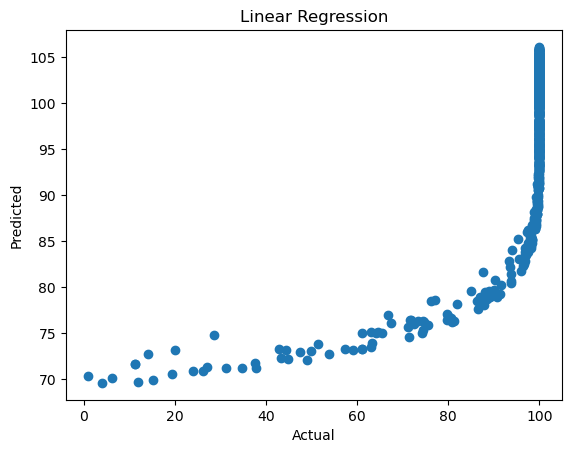

In [17]:
plt.figure()

plt.scatter(y_test, y_pred_test_lin)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")

plt.show()